The previous notebooks showed that simple return forecasting is difficult using a mean baseline or AR(1) model. However, the empirical return distribution showed heavier tails than the fitted Gaussian model. This motivates replacing the Gaussian error assumption with a Student-t likelihood.

Import cleaned returns, and recreate train/test split.

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

print("Working environment ready.")

Working environment ready.


In [2]:
from pathlib import Path

cwd = Path.cwd()

if cwd.name == "notebooks":
    project_root = cwd.parent
else:
    project_root = cwd

figures_dir = project_root / "figures"
figures_dir.mkdir(exist_ok=True)

figures_dir

WindowsPath('c:/Users/jtsam/Coding/bayesian-times-series-finance/figures')

In [3]:
ticker = "QQQ"

qqq = yf.download(
    ticker,
    start="2015-01-01",
    auto_adjust=True,
    progress=False
)

prices = qqq[["Close"]].copy()
prices = prices.rename(columns={"Close": "QQQ_close"})

prices["QQQ_log_return"] = np.log(
    prices["QQQ_close"] / prices["QQQ_close"].shift(1)
)

returns = prices["QQQ_log_return"].dropna()

returns.head()

Date
2015-01-05   -0.014777
2015-01-06   -0.013499
2015-01-07    0.012808
2015-01-08    0.018959
2015-01-09   -0.006605
Name: QQQ_log_return, dtype: float64

In [4]:
ar_data = pd.DataFrame({
    "return_t": returns,
    "return_lag_1": returns.shift(1)
}).dropna()

ar_data.head()

,return_t,return_lag_1
Date,,
2015-01-06,-0.013499,-0.014777
2015-01-07,0.012808,-0.013499
2015-01-08,0.018959,0.012808
2015-01-09,-0.006605,0.018959
2015-01-12,-0.010482,-0.006605


In [5]:
split_index = int(len(ar_data) * 0.8)

train = ar_data.iloc[:split_index]
test = ar_data.iloc[split_index:]

print(f"Training set size: {len(train)}")
print(f"Test set size: {len(test)}")

print(f"Training set date range: {train.index.min().date()} to {train.index.max().date()}")
print(f"Test set date range: {test.index.min().date()} to {test.index.max().date()}")

Training set size: 2300
Test set size: 576
Training set date range: 2015-01-06 to 2024-02-26
Test set date range: 2024-02-27 to 2026-06-12


Set up Bayesian AR(1) model structure, where the intercept, autoregressive coefficient, and noise scale each have prior probability distributions. The observed training returns updates these priors into posterior distributions, which are then used to generate one-step-ahead predictive distributions for the test period.

In [6]:
X_train = train["return_lag_1"]
y_train = train["return_t"]

X_test = test["return_lag_1"]
y_test = test["return_t"]

Scale data so it is easier to work with using PyMC. Data is scaled by 100 so daily log returns becomes daily percentage log returns. PyMC helps model the parameters as probability distributions.

In [8]:
X_train_scaled = X_train * 100
y_train_scaled = y_train * 100

X_test_scaled = X_test * 100
y_test_scaled = y_test * 100

Import relevant libraries to model and visualise Bayesian statistical models.

In [7]:
import pymc as pm
import arviz as az

g++ not available, if using conda: `conda install gxx`


## Bayesian AR(1) model

The Bayesian AR(1) model assumes that today's return depends linearly on yesterday's return, with normally distributed noise:

$$
r_t = \alpha + \phi (r_{t-1}) + \epsilon_t
$$

where

$$
\epsilon_t \sim \mathcal{N}(0, \sigma^2)
$$

Equivalently, the likelihood can be written as

$$
r_t \mid r_{t-1}, \alpha, \phi, \sigma \sim \mathcal{N}(\alpha + \phi r_{t-1}, \sigma^2)
$$

The model parameters are given prior distributions:

$$
\alpha \sim \mathcal{N}(0, 1)
$$

$$
\phi \sim \mathcal{N}(0, 0.5^2)
$$

$$
\sigma \sim \text{HalfNormal}(2)
$$

Here, $\alpha$ is the intercept, $\phi$ is the autoregressive coefficient, and $\sigma$ is the noise scale. The observed training returns update these prior beliefs into posterior distributions for the parameters. These posterior distributions are then used to generate one-step-ahead predictive distributions for the test period.

In [9]:
with pm.Model() as bayesian_ar1:

    alpha = pm.Normal("alpha", mu=0, sigma=1)
    phi = pm.Normal("phi", mu=0, sigma=0.5)
    sigma = pm.HalfNormal("sigma", sigma=2)

    mu = alpha + phi * X_train_scaled.values

    return_obs = pm.Normal(
        "return_obs",
        mu=mu,
        sigma=sigma,
        observed=y_train_scaled.values
    )

    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, phi, sigma]


c:\Users\jtsam\Coding\bayesian-times-series-finance\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 22 seconds.


Check the posterior: phi should be close to zero because you expect that yesterday's return does not strongly predict today's return. Recall all values are now given as percentages.

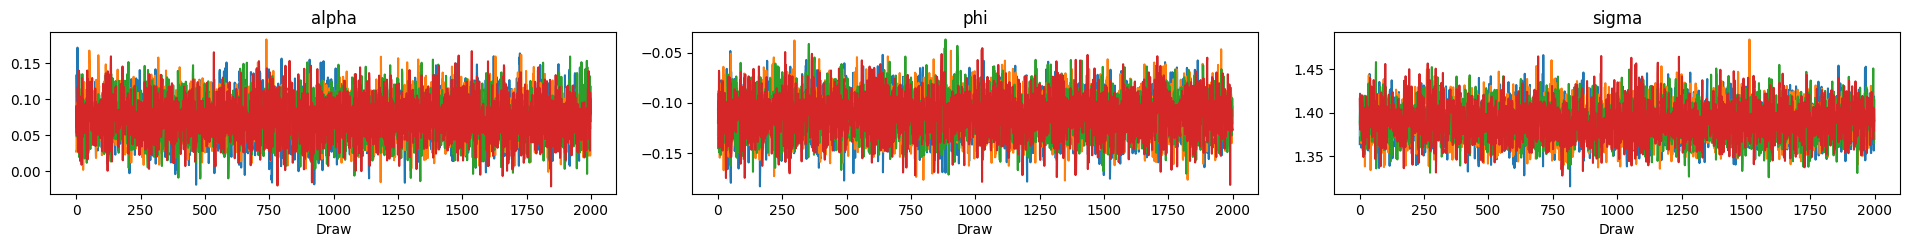

In [ ]:
az.plot_trace(trace, var_names=["alpha", "phi", "sigma"])
plt.tight_layout()
plt.savefig(figures_dir / "bayesian_ar1_trace.png", dpi=300)
plt.show()

In [11]:
az.summary(trace, var_names=["alpha", "phi", "sigma"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,0.074,0.0289,0.028,0.12,7422,6090,1.00,0.00034,0.00023
phi,-0.1119,0.0206,-0.14,-0.079,9035,6324,1.00,0.00022,0.00015
sigma,1.39,0.0202,1.4,1.4,8016,5967,1.00,0.00023,0.00016


Now forecast on the test set. Create many possible predictions for each test date.

In [12]:
posterior = trace.posterior

alpha_samples = posterior["alpha"].values.flatten()
phi_samples = posterior["phi"].values.flatten()
sigma_samples = posterior["sigma"].values.flatten()

n_samples = len(alpha_samples)
n_test = len(X_test_scaled)

posterior_predictions = np.zeros((n_samples, n_test))

for i in range(n_samples):
    posterior_predictions[i, :] = (
        alpha_samples[i]
        + phi_samples[i] * X_test_scaled.values
        + np.random.normal(0, sigma_samples[i], size=n_test)
    )


Summarise and plot predictions.

In [15]:
pred_mean = posterior_predictions.mean(axis=0)
pred_lower = np.percentile(posterior_predictions, 2.5, axis=0)
pred_upper = np.percentile(posterior_predictions, 97.5, axis=0)

predictions_df = pd.DataFrame(
    {
        "actual": y_test_scaled.values,
        "pred_mean": pred_mean,
        "pred_lower": pred_lower,
        "pred_upper": pred_upper
    },
    index=y_test_scaled.index
)

predictions_df.head()

,actual,pred_mean,pred_lower,pred_upper
Date,,,,
2024-02-27,0.240236,0.102520,-2.660742,2.849363
2024-02-28,-0.533877,0.054792,-2.644961,2.693698
2024-02-29,0.853287,0.146924,-2.626196,2.866196
2024-03-01,1.494460,-0.047585,-2.691782,2.769978
2024-03-04,-0.357438,-0.080071,-2.811225,2.706306


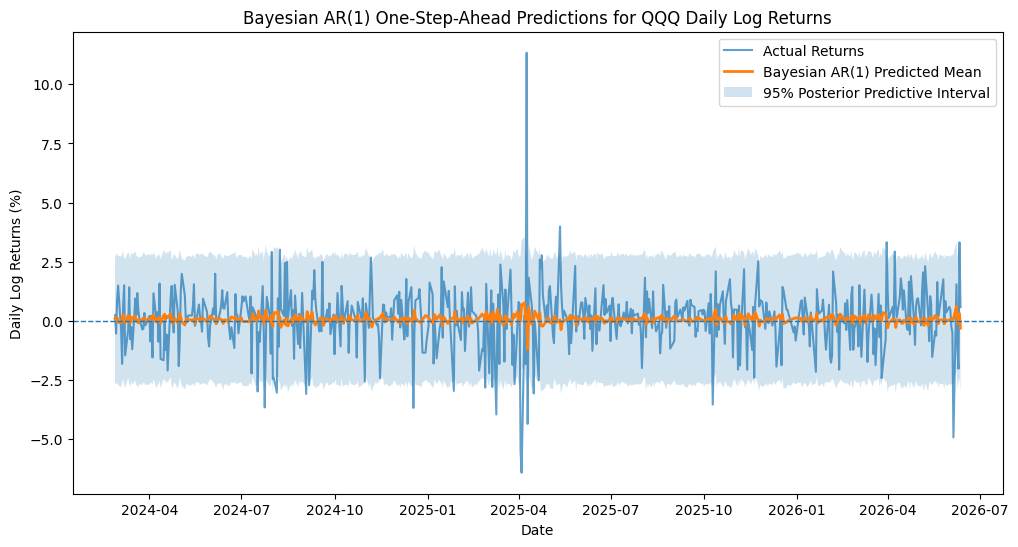

In [18]:
plt.subplots(figsize=(12, 6))

plt.plot(
    predictions_df.index,
    predictions_df["actual"],
    label="Actual Returns",
    alpha=0.7
)

plt.plot(
    predictions_df.index,
    predictions_df["pred_mean"],
    label="Bayesian AR(1) Predicted Mean",
    linewidth=2,
)

plt.fill_between(
    predictions_df.index,
    predictions_df["pred_lower"],
    predictions_df["pred_upper"],
    alpha=0.2,
    label="95% Posterior Predictive Interval"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Bayesian AR(1) One-Step-Ahead Predictions for QQQ Daily Log Returns")
plt.xlabel("Date")
plt.ylabel("Daily Log Returns (%)")
plt.legend()
plt.savefig(figures_dir / "bayesian_ar1_predictions.png", dpi=300)
plt.show()

The Bayesian AR(1) model produces predicted mean returns that remain close to zero throughout the test period. Although the posterior distribution for the AR(1) coefficient suggests a weak negative relationship between consecutive daily returns, this effect is small compared with the estimated noise scale.

The 95% posterior predictive interval captures most of the observed test returns, but some extreme return shocks fall outside the interval. This is consistent with the earlier exploratory analysis, where the empirical return distribution showed heavier tails than a Gaussian distribution.

Overall, the Bayesian AR(1) model provides a useful first probabilistic baseline, but it has limited predictive power for daily returns. The model captures uncertainty in the conditional mean, but it does not model time-varying volatility or extreme tail behaviour. This motivates moving next towards volatility models such as GARCH or Bayesian stochastic volatility once a Student-t model is examined.

#### The same pattern for the Bayesian AR-1 model is now applied but with a student-t model instead, to account for the heavier tails.

In [ ]:
with pm.Model() as bayesian_ar1_student_t:

    alpha = pm.Normal("alpha", mu=0, sigma=1)
    phi = pm.Normal("phi", mu=0, sigma=0.5)
    sigma = pm.HalfNormal("sigma", sigma=2)
    nu = pm.Exponential("nu", lam=1/20)

    mu = alpha + phi * X_train_scaled.values

    return_obs = pm.StudentT(
        "return_obs",
        nu=nu,
        mu=mu,
        sigma=sigma,
        observed=y_train_scaled.values
    )

    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42
    )